# Temporal Rescale Analysis on Skeleton Data

This notebook analyzes the effect of temporal rescaling on skeleton sequence data and produces two academic-style figures:

1. **Figure 1 — Frame Presence Comparison:** Side-by-side timeline of which frames are retained, dropped, or compressed under each augmentation strategy (Original / Temporal Drop / Temporal Rescale).

2. **Figure 2 — Sequence Length Distribution:** Histograms and boxplot comparing sequence lengths before and after augmentation, showing how the length distribution shifts.


In [2]:
import pickle
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patheffects as pe
import random, sys, os

# Add parent directory to path to allow importing from 'src'
sys.path.append('..')

# ── Paper palette (IEEE/Elsevier style) ──────────────────────────────────────
C_ORI  = '#2166AC'   # deep blue  – original
C_DROP = '#B2182B'   # dark red   – temporal drop
C_RESC = '#1A7A4A'   # dark green – temporal rescale
C_MISS = '#F4A582'   # salmon     – dropped frames
C_VOID = '#E0E0E0'   # light grey – empty frames

PAPER_RC = {
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
    'axes.edgecolor'    : '#444444',
    'axes.linewidth'    : 0.7,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : False,
    'font.family'       : 'serif',
    'font.serif'        : ['Times New Roman', 'DejaVu Serif', 'serif'],
    'font.size'         : 9,
    'axes.titlesize'    : 9,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 8,
    'xtick.labelsize'   : 7.5,
    'ytick.labelsize'   : 7.5,
    'xtick.major.width' : 0.6,
    'ytick.major.width' : 0.6,
    'xtick.major.size'  : 3,
    'ytick.major.size'  : 3,
    'legend.fontsize'   : 7.5,
    'legend.framealpha' : 0.9,
    'legend.edgecolor'  : '#cccccc',
    'figure.titlesize'  : 10,
    'figure.titleweight': 'bold',
    'lines.linewidth'   : 1.0,
    'patch.linewidth'   : 0.5,
    'savefig.dpi'       : 300,
    'savefig.bbox'      : 'tight',
}
plt.rcParams.update(PAPER_RC)

pickle_file = '../data/pickle/pose_bisindo.pkl'
with open(pickle_file, 'rb') as f:
    data = pickle.load(f)

print(f"Total videos in dataset: {len(data)}")
print("Sample Video IDs:", list(data.keys())[:10])


Total videos in dataset: 807
Sample Video IDs: ['P1_S01_R1', 'P1_S01_R2', 'P1_S01_R3', 'P1_S01_R4', 'P1_S01_R5', 'P2_S01_R1', 'P2_S01_R2', 'P2_S01_R3', 'P2_S01_R4', 'P2_S01_R5']


In [3]:
# ============================================================
#   PARAMETER SETTINGS
# ============================================================
SELECTED_VIDEO_ID   = 'P1_S01_R1'   # Target video for analysis
SELECTED_START_FRAME = 35              # Starting frame for visualization
N_FRAMES_SHOW = 5                      # How many consecutive frames to show
TEMPORAL_RESCALE_TARGET = 0.5          # Target scale (e.g., 0.5 = half, 2.0 = double)
RANDOM_SEED          = 42              # Reproducibility
# ============================================================

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

if SELECTED_VIDEO_ID not in data:
    raise ValueError(f"Video '{SELECTED_VIDEO_ID}' not found!")

kp = data[SELECTED_VIDEO_ID]['keypoints']  # shape: (T, K, 2)
T, K, _ = kp.shape

print(f"Video           : {SELECTED_VIDEO_ID}")
print(f"Total frames    : {T}")
print(f"Total keypoints : {K} per frame")
print(f"Using frames    : {SELECTED_START_FRAME} – {SELECTED_START_FRAME + N_FRAMES_SHOW - 1}")

Video           : P1_S01_R1
Total frames    : 115
Total keypoints : 86 per frame
Using frames    : 35 – 39


## Figure 1 — Frame Presence: Original vs. Temporal Drop vs. Temporal Rescale

Visual timeline comparing frame retention under each augmentation strategy.


In [12]:
import sys

if "src.utils.skeleton_augmentation" in sys.modules:
    del sys.modules["src.utils.skeleton_augmentation"]

import src.utils.skeleton_augmentation as aug

print(dir(aug))

['Compose', 'Downsample', 'Dropout_kp', 'EPS', 'Jitter', 'SENTENCE_LENGTH_BOUNDS', 'Scale', 'Spatial_flip', 'TemporalCrop', 'TemporalDropout', 'TemporalRescale', 'TemporalRescale_test', 'ToTensor', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'np', 'random', 'torch']


Original: 115  |  Drop: 94 (−21, 18.3%)  |  Rescale: 100


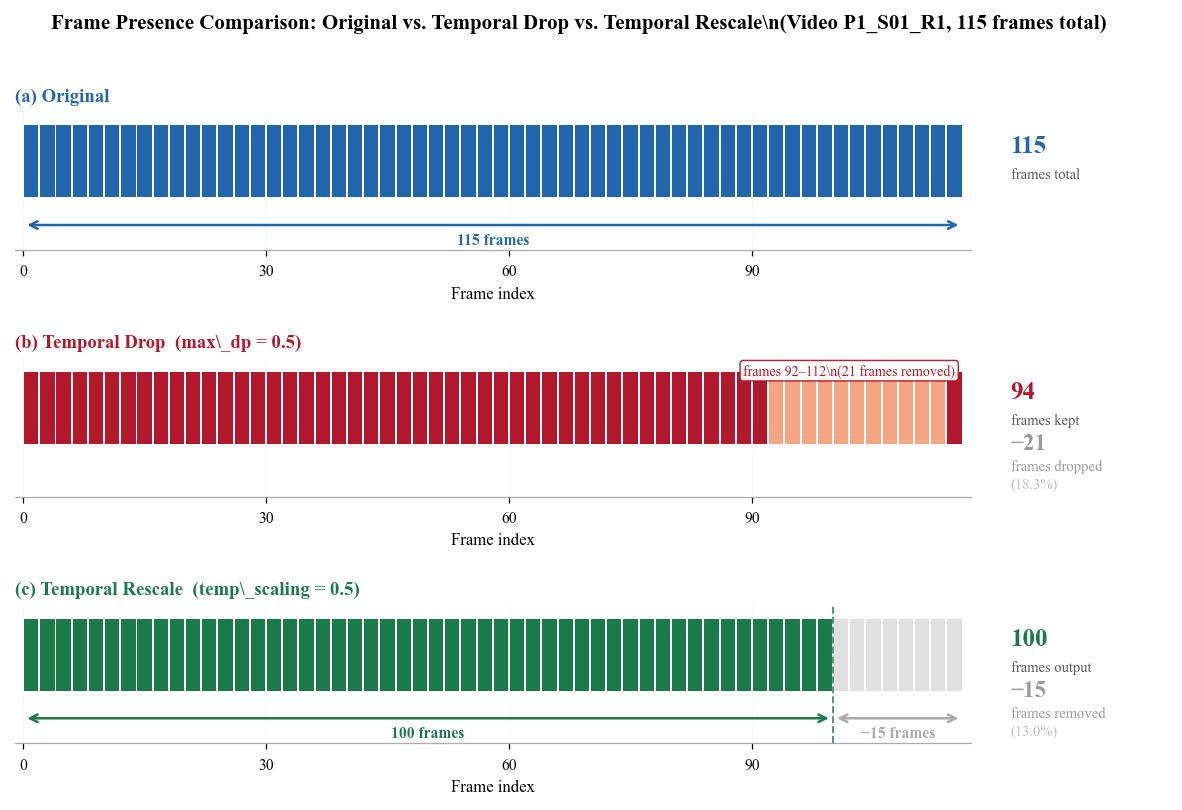

Done.


In [14]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import numpy as np
from src.utils.skeleton_augmentation import TemporalRescale, TemporalDropout

# ── Config ────────────────────────────────────────────────────────────────────
speaker_id, sequence_id, rep_id = "P1", "S01", "R1"
TOTAL_FRAMES, SEED, BLOCK_SIZE  = 185, 42, 2

# ── Load & augment ────────────────────────────────────────────────────────────
match    = [k for k in data.keys() if k.startswith(f"{speaker_id}_{sequence_id}_{rep_id}")]
vid      = sorted(match)[0]
clip_ori = data[vid]['keypoints'][:TOTAL_FRAMES].copy()
T_ori    = len(clip_ori)

np.random.seed(SEED)
clip_drop = TemporalDropout(max_dp=0.5)(clip_ori.copy())
T_drop    = len(clip_drop)

np.random.seed(SEED)
clip_resc = TemporalRescale(temp_scaling=0.5)(clip_ori.copy())
T_resc    = len(clip_resc)

def get_dropped(original, dropped_clip):
    kept, ptr = [], 0
    for i in range(len(original)):
        if ptr < len(dropped_clip) and np.allclose(original[i], dropped_clip[ptr], atol=1e-5):
            kept.append(i); ptr += 1
    return set(i for i in range(len(original)) if i not in kept)

dropped_set = get_dropped(clip_ori, clip_drop)
n_dropped   = len(dropped_set)
n_kept      = T_drop
n_blocks    = int(np.ceil(T_ori / BLOCK_SIZE))
resc_blocks = int(np.ceil(T_resc / BLOCK_SIZE))

def block_is_dropped(b):
    frames = range(b * BLOCK_SIZE, min((b+1)*BLOCK_SIZE, T_ori))
    return sum(1 for f in frames if f in dropped_set) >= max(1, len(list(frames)) / 2)

clusters = []
if dropped_set:
    sd = sorted(dropped_set); s = p = sd[0]
    for d in sd[1:]:
        if d == p+1: p = d
        else: clusters.append((s, p)); s = p = d
    clusters.append((s, p))
best = max(clusters, key=lambda c: c[1]-c[0])

print(f"Original: {T_ori}  |  Drop: {T_drop} (−{n_dropped}, {n_dropped/T_ori*100:.1f}%)  |  Rescale: {T_resc}")

# ── Figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(8.0, 5.4), dpi=150)
fig.patch.set_facecolor('white')
gs = gridspec.GridSpec(3, 2, figure=fig,
    hspace=0.78, wspace=0.04,
    width_ratios=[5.5, 1],
    top=0.86, bottom=0.08, left=0.03, right=0.99)

BAR_H, Y_BAR, Y_BRK, BW = 0.52, 0.64, 0.18, 0.88
step  = max(1, round(30 / BLOCK_SIZE))
ticks = np.arange(0, n_blocks+1, step)
tlabs = [str(int(t * BLOCK_SIZE)) for t in ticks]

def make_bar_ax(gs_cell):
    ax = fig.add_subplot(gs_cell)
    ax.set_xlim(-0.5, n_blocks + 0.5); ax.set_ylim(0, 1)
    ax.set_yticks([]); ax.set_xticks(ticks); ax.set_xticklabels(tlabs)
    ax.set_xlabel("Frame index", labelpad=3)
    ax.grid(axis='x', alpha=0.12, lw=0.4, zorder=1)
    for sp in ['top','right','left']: ax.spines[sp].set_visible(False)
    ax.spines['bottom'].set_linewidth(0.6); ax.spines['bottom'].set_color('#aaaaaa')
    return ax

def make_info_ax(gs_cell):
    ax = fig.add_subplot(gs_cell)
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis('off')
    return ax

def draw_blocks(ax, colors):
    for b, fc in enumerate(colors):
        ax.add_patch(mpatches.FancyBboxPatch(
            (b+(1-BW)/2, Y_BAR-BAR_H/2), BW, BAR_H,
            boxstyle="square,pad=0", facecolor=fc, edgecolor='none', zorder=3))

def bracket(ax, x0, x1, y, color, label):
    ax.annotate('', xy=(x1,y), xytext=(x0,y),
                arrowprops=dict(arrowstyle='<->', color=color, lw=1.2))
    ax.text((x0+x1)/2, y-0.06, label,
            ha='center', va='top', fontsize=7.5, color=color, fontweight='bold')

def info_text(ax, val, unit, val2=None, unit2=None, pct=None, c_val=C_ORI):
    ax.text(0.1, 0.75, val,  fontsize=12, fontweight='bold', color=c_val, va='center', ha='left')
    ax.text(0.1, 0.55, unit, fontsize=7,  color='#555555',   va='center', ha='left')
    if val2 is not None:
        ax.text(0.1, 0.38, val2,  fontsize=11, fontweight='bold', color='#999999', va='center', ha='left')
        ax.text(0.1, 0.22, unit2, fontsize=7,  color='#999999',   va='center', ha='left')
        ax.text(0.1, 0.09, pct,   fontsize=7,  color='#bbbbbb',   va='center', ha='left')

# ── Row 0 – Original ──────────────────────────────────────────────────────────
ax0  = make_bar_ax(gs[0,0]); ax0i = make_info_ax(gs[0,1])
draw_blocks(ax0, [C_ORI]*n_blocks)
bracket(ax0, 0, n_blocks, Y_BRK, C_ORI, f'{T_ori} frames')
ax0.set_title("(a) Original", color=C_ORI, loc='left', pad=5)
info_text(ax0i, f"{T_ori}", "frames total", c_val=C_ORI)

# ── Row 1 – Temporal Drop ─────────────────────────────────────────────────────
ax1  = make_bar_ax(gs[1,0]); ax1i = make_info_ax(gs[1,1])
draw_blocks(ax1, [C_MISS if block_is_dropped(b) else C_DROP for b in range(n_blocks)])
ax1.set_title("(b) Temporal Drop  (max\\_dp = 0.5)", color=C_DROP, loc='left', pad=5)
mid_b = ((best[0]//BLOCK_SIZE) + (best[1]//BLOCK_SIZE)) / 2
ax1.annotate(
    f"frames {best[0]}–{best[1]}\\n({best[1]-best[0]+1} frames removed)",
    xy=(mid_b, Y_BAR+BAR_H/2+0.01), xytext=(mid_b, 0.96),
    ha='center', va='top', fontsize=6.8, color=C_DROP,
    arrowprops=dict(arrowstyle='->', color=C_DROP, lw=0.8),
    bbox=dict(boxstyle='round,pad=0.22', fc='white', ec=C_DROP, alpha=0.95, lw=0.7))
info_text(ax1i, f"{n_kept}", "frames kept",
          f"−{n_dropped}", "frames dropped", f"({n_dropped/T_ori*100:.1f}%)", C_DROP)

# ── Row 2 – Temporal Rescale ──────────────────────────────────────────────────
ax2  = make_bar_ax(gs[2,0]); ax2i = make_info_ax(gs[2,1])
draw_blocks(ax2, [C_RESC if b < resc_blocks else C_VOID for b in range(n_blocks)])
ax2.axvline(resc_blocks, color=C_RESC, ls='--', lw=0.9, alpha=0.8, zorder=4)
bracket(ax2, 0, resc_blocks, Y_BRK, C_RESC, f'{T_resc} frames')
if resc_blocks < n_blocks:
    bracket(ax2, resc_blocks, n_blocks, Y_BRK, '#AAAAAA', f'−{T_ori-T_resc} frames')
ax2.set_title("(c) Temporal Rescale  (temp\\_scaling = 0.5)", color=C_RESC, loc='left', pad=5)
info_text(ax2i, f"{T_resc}", "frames output",
          f"−{T_ori-T_resc}", "frames removed", f"({(T_ori-T_resc)/T_ori*100:.1f}%)", C_RESC)

fig.suptitle(
    f"Frame Presence Comparison: Original vs. Temporal Drop vs. Temporal Rescale\\n"
    f"(Video {speaker_id}_{sequence_id}_{rep_id}, {T_ori} frames total)",
)
plt.savefig("fig1_frame_presence.pdf"); plt.savefig("fig1_frame_presence.png")
plt.show(); print("Done.")

## Figure 2 — Sequence Length Distribution

Histograms and boxplot comparing sequence lengths before and after temporal augmentation across all videos in the dataset.


C:\Users\IKAJTK\AppData\Local\Temp\ipykernel_23264\2606334760.py:58: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(


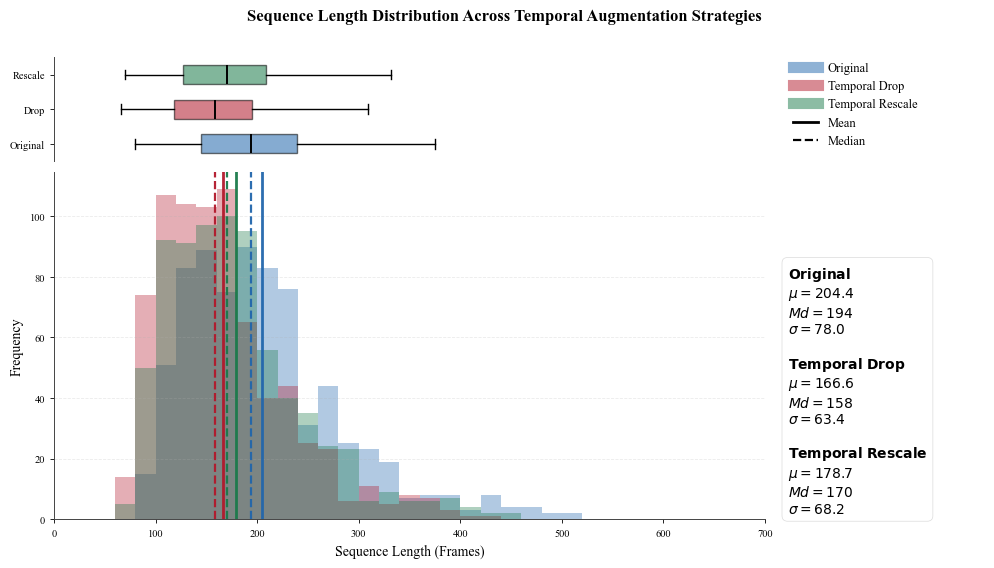

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

# =========================================================
# COMPUTE STATISTICS FROM REAL DATA
# =========================================================

def get_stats(arr):
    return {
        "mean": np.mean(arr),
        "median": np.median(arr),
        "std": np.std(arr),
        "min": np.min(arr),
        "max": np.max(arr),
    }

stats_ori  = get_stats(orig_lens)
stats_drop = get_stats(drop_lens)
stats_resc = get_stats(resc_lens)

# =========================================================
# FIGURE STYLE
# =========================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "legend.fontsize": 9,
})

# =========================================================
# FIGURE LAYOUT
# =========================================================

fig = plt.figure(figsize=(12, 6))

gs = gridspec.GridSpec(
    2,
    2,
    width_ratios=[4.7, 1.3],
    height_ratios=[0.9, 3],
    wspace=0.05,
    hspace=0.05
)

ax_box  = fig.add_subplot(gs[0, 0])
ax_hist = fig.add_subplot(gs[1, 0])
ax_side = fig.add_subplot(gs[:, 1])

# =========================================================
# BOXPLOT
# =========================================================

bp = ax_box.boxplot(
    [orig_lens, drop_lens, resc_lens],
    vert=False,
    widths=0.55,
    patch_artist=True,
    labels=["Original", "Drop", "Rescale"],
    showfliers=False
)

colors = [C_ORI, C_DROP, C_RESC]

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.55)

for median in bp['medians']:
    median.set_color("black")
    median.set_linewidth(1.4)

ax_box.set_xlim(0, 700)

ax_box.spines['top'].set_visible(False)
ax_box.spines['right'].set_visible(False)
ax_box.spines['bottom'].set_visible(False)

ax_box.tick_params(
    axis='x',
    which='both',
    bottom=False,
    labelbottom=False
)

# =========================================================
# HISTOGRAM
# =========================================================

bins = np.arange(0, 701, 20)

hist_style = dict(
    bins=bins,
    histtype='stepfilled',
    edgecolor='none',
    alpha=0.35
)

ax_hist.hist(
    orig_lens,
    color=C_ORI,
    label='Original',
    **hist_style
)

ax_hist.hist(
    drop_lens,
    color=C_DROP,
    label='Temporal Drop',
    **hist_style
)

ax_hist.hist(
    resc_lens,
    color=C_RESC,
    label='Temporal Rescale',
    **hist_style
)

# =========================================================
# MEAN & MEDIAN LINES
# =========================================================

stats_list = [stats_ori, stats_drop, stats_resc]

for stats, color in zip(stats_list, colors):

    # Mean
    ax_hist.axvline(
        stats["mean"],
        color=color,
        linestyle='-',
        linewidth=2.0,
        alpha=0.95
    )

    # Median
    ax_hist.axvline(
        stats["median"],
        color=color,
        linestyle='--',
        linewidth=1.6,
        alpha=0.95
    )

# =========================================================
# AXIS STYLE
# =========================================================

ax_hist.set_xlim(0, 700)

ax_hist.set_xlabel("Sequence Length (Frames)")
ax_hist.set_ylabel("Frequency")

ax_hist.grid(
    axis='y',
    linestyle='--',
    linewidth=0.6,
    alpha=0.25
)

ax_hist.spines['top'].set_visible(False)
ax_hist.spines['right'].set_visible(False)

# =========================================================
# SIDE PANEL
# =========================================================

ax_side.axis('off')

# ---------- LEGEND ----------

legend_handles = [
    Line2D([0], [0], color=C_ORI,  lw=8, alpha=0.5),
    Line2D([0], [0], color=C_DROP, lw=8, alpha=0.5),
    Line2D([0], [0], color=C_RESC, lw=8, alpha=0.5),
    Line2D([0], [0], color='black', lw=2.0, linestyle='-'),
    Line2D([0], [0], color='black', lw=1.6, linestyle='--'),
]

legend_labels = [
    'Original',
    'Temporal Drop',
    'Temporal Rescale',
    'Mean',
    'Median'
]

ax_side.legend(
    legend_handles,
    legend_labels,
    loc='upper left',
    frameon=False,
    borderaxespad=0
)

# ---------- STATISTICS ----------

stats_text = (
    r"$\bf{Original}$" "\n"
    rf"$\mu={stats_ori['mean']:.1f}$" "\n"
    rf"$Md={stats_ori['median']:.0f}$" "\n"
    rf"$\sigma={stats_ori['std']:.1f}$"
    "\n\n"
    r"$\bf{Temporal\ Drop}$" "\n"
    rf"$\mu={stats_drop['mean']:.1f}$" "\n"
    rf"$Md={stats_drop['median']:.0f}$" "\n"
    rf"$\sigma={stats_drop['std']:.1f}$"
    "\n\n"
    r"$\bf{Temporal\ Rescale}$" "\n"
    rf"$\mu={stats_resc['mean']:.1f}$" "\n"
    rf"$Md={stats_resc['median']:.0f}$" "\n"
    rf"$\sigma={stats_resc['std']:.1f}$"
)

ax_side.text(
    0.0,
    0.55,
    stats_text,
    fontsize=10,
    va='top',
    ha='left',
    bbox=dict(
        facecolor='white',
        edgecolor='0.85',
        boxstyle='round,pad=0.4',
        alpha=0.95
    )
)

# =========================================================
# TITLE
# =========================================================

fig.suptitle(
    "Sequence Length Distribution Across Temporal Augmentation Strategies",
    fontsize=12,
    fontweight='bold',
    y=0.96
)

# =========================================================
# SAVE
# =========================================================

plt.savefig(
    "fig2_length_distribution_final.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()